Multi-Asset Bollinger Band Portfolio
=======================

This tutorial demonstrates how to use `PortfolioBacktest` to trade several
assets in one shared account.

This is different from `backtesting.lib.MultiBacktest`. `MultiBacktest` runs
the same single-asset strategy independently on many datasets. `PortfolioBacktest`
runs one strategy across many symbols with shared cash, margin, orders, trades,
and portfolio-level equity.

The example below uses a Bollinger Band mean-reversion strategy. For each
symbol, the strategy buys when price closes below the lower band and closes the
position when price reverts above the middle band. The strategy is long-only so
the portfolio mechanics are easy to inspect.

## Imports

We will use the bundled `GOOG` sample data as a starting point and derive a few
synthetic assets from it. This keeps the notebook fully self-contained and
guarantees that every asset has the same timestamp index.

In real projects, replace the synthetic data dictionary with real OHLCV
dataframes keyed by symbol, e.g. `{"AAPL": aapl_df, "MSFT": msft_df}`.

In [1]:
import numpy as np
import pandas as pd

from backtesting import PortfolioBacktest, Strategy
from backtesting.test import GOOG

/home/ubuntu/projects/backtesting.py/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

## Prepare Aligned Multi-Asset Data

`PortfolioBacktest` expects a mapping of symbol names to OHLCV dataframes.
All assets are aligned to a common index. The current implementation uses an
inner join, so only timestamps present in all assets are traded.

The helper below creates deterministic synthetic assets from `GOOG`. It keeps
valid OHLC relationships by applying one positive scale factor to every OHLC
price on the same bar.

In [2]:
def make_synthetic_asset(base, *, seed, drift=0.0, volatility=1.0, volume_scale=1.0):
    rng = np.random.default_rng(seed)
    base = base.copy(deep=False)

    returns = base.Close.pct_change().fillna(0)
    noise = rng.normal(0, 0.006, len(base))
    synthetic_returns = returns * volatility + drift / 252 + noise
    synthetic_returns = synthetic_returns.clip(-0.25, 0.25)

    synthetic_close = base.Close.iloc[0] * np.cumprod(1 + synthetic_returns)
    scale = synthetic_close / base.Close

    df = base[["Open", "High", "Low", "Close"]].mul(scale, axis=0)
    df["Volume"] = (
        base.Volume
        * volume_scale
        * rng.lognormal(mean=0, sigma=0.15, size=len(base))
    )
    return df


data = {
    "GOOG": GOOG,
    "ALPHA": make_synthetic_asset(GOOG, seed=1, drift=0.05, volatility=0.75, volume_scale=1.2),
    "BETA": make_synthetic_asset(GOOG, seed=2, drift=-0.02, volatility=1.25, volume_scale=0.8),
    "GAMMA": make_synthetic_asset(GOOG, seed=3, drift=0.02, volatility=1.60, volume_scale=0.6),
}

{symbol: frame.shape for symbol, frame in data.items()}

{'GOOG': (2148, 5), 'ALPHA': (2148, 5), 'BETA': (2148, 5), 'GAMMA': (2148, 5)}

A quick normalized-close plot helps confirm that the assets share an index but
behave differently.

<Axes: title={'center': 'Normalized close prices'}>

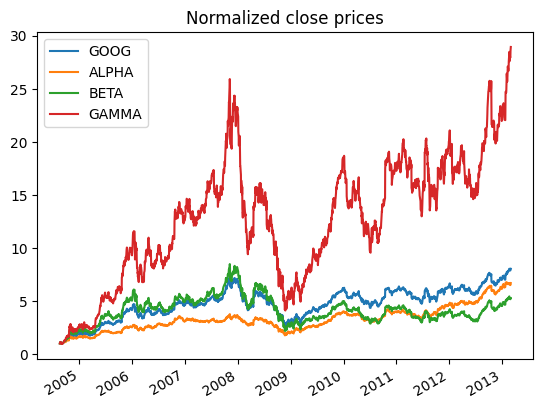

In [3]:
normalized_closes = pd.DataFrame(
    {symbol: frame.Close / frame.Close.iloc[0] for symbol, frame in data.items()}
)
normalized_closes.plot(title="Normalized close prices")

## Bollinger Bands

Bollinger Bands consist of:

* a middle band, usually a rolling mean;
* an upper band, rolling mean plus some number of rolling standard deviations;
* a lower band, rolling mean minus some number of rolling standard deviations.

This function is causal for an end-of-bar strategy: each band value uses the
current completed bar and previous bars only. In the default execution model,
decisions made from bar `t` data fill no earlier than bar `t + 1` open.

In [4]:
def bollinger_bands(close, lookback, n_std):
    close = pd.Series(close)
    middle = close.rolling(lookback).mean()
    std = close.rolling(lookback).std()
    upper = middle + n_std * std
    lower = middle - n_std * std
    return middle, upper, lower

## Define A Portfolio Strategy

In a `PortfolioBacktest` strategy:

* `self.data.symbols` lists all symbols;
* `self.data[symbol]` returns that symbol's OHLCV data accessor;
* `self.buy(symbol, ...)` and `self.sell(symbol, ...)` place symbol-specific orders;
* `self.position[symbol]` inspects or closes one symbol's current position.

The indicator dictionaries below are the main pattern to notice. Each symbol
gets its own middle, upper, and lower band arrays. `size=.20` requests 20% of
the same-bar portfolio buying-power snapshot when the order is processed; it
is not a continuously rebalanced 20% target weight.

In [ ]:
class BollingerPortfolioStrategy(Strategy):
    lookback = 20
    n_std = 2
    allocation = 0.20

    def init(self):
        self.middle = {}
        self.upper = {}
        self.lower = {}

        for symbol in self.data.symbols:
            bands = self.I(
                bollinger_bands,
                self.data[symbol].Close,
                self.lookback,
                self.n_std,
                name=(
                    f"{symbol} middle",
                    f"{symbol} upper",
                    f"{symbol} lower",
                ),
            )
            self.middle[symbol] = bands[0]
            self.upper[symbol] = bands[1]
            self.lower[symbol] = bands[2]

    def next(self):
        for symbol in self.data.symbols:
            close = self.data[symbol].Close
            price = close[-1]
            position = self.position[symbol]

            if not position and price < self.lower[symbol][-1]:
                self.buy(symbol, size=self.allocation)

            elif position.is_long and price > self.middle[symbol][-1]:
                position.close()

## Run The Backtest

This is one portfolio-level simulation. Cash is shared across the four symbols,
and every order competes for the same margin and liquidity. If symbols trade on
different calendars, `PortfolioBacktest` currently uses the common index and
warns about any rows that are dropped before the run starts.

In [14]:
bt = PortfolioBacktest(
    data,
    BollingerPortfolioStrategy,
    cash=100_000,
    commission=0.001,
    finalize_trades=True,
)

stats = bt.run()
stats

PortfolioBacktest.run:   0%|          | 0/2118 [00:00<?, ?bar/s]

Start                     2004-08-19 00:00:00
End                       2013-03-01 00:00:00
Duration                   3116 days 00:00:00
Exposure Time [%]                    39.57169
Equity Final [$]                  99719.80547
Equity Peak [$]                  115321.77787
Commissions [$]                    3771.01434
Return [%]                           -0.28019
Buy & Hold Return [%]               816.82515
Return (Ann.) [%]                    -0.03291
Volatility (Ann.) [%]                11.51428
CAGR [%]                             -0.02269
Sharpe Ratio                         -0.00286
Sortino Ratio                        -0.00408
Calmar Ratio                         -0.00085
Alpha [%]                          -136.31714
Beta                                  0.16654
Max. Drawdown [%]                   -38.59986
Avg. Drawdown [%]                     -4.6043
Max. Drawdown Duration     2032 days 00:00:00
Avg. Drawdown Duration      205 days 00:00:00
# Trades                          

## Inspect Trades

The result shape is the same as `Backtest.run()`, with one important addition:
the trades dataframe includes a `Symbol` column.

In [15]:
trades = stats["_trades"]
trades.head()

,Symbol,Size,EntryBar,ExitBar,EntryPrice,ExitPrice,SL,TP,PnL,Commission,...,"Entry_['BETA middle', 'BETA upper', 'BETA lower']_1","Exit_['BETA middle', 'BETA upper', 'BETA lower']_1","Entry_['BETA middle', 'BETA upper', 'BETA lower']_2","Exit_['BETA middle', 'BETA upper', 'BETA lower']_2","Entry_['GAMMA middle', 'GAMMA upper', 'GAMMA lower']_0","Exit_['GAMMA middle', 'GAMMA upper', 'GAMMA lower']_0","Entry_['GAMMA middle', 'GAMMA upper', 'GAMMA lower']_1","Exit_['GAMMA middle', 'GAMMA upper', 'GAMMA lower']_1","Entry_['GAMMA middle', 'GAMMA upper', 'GAMMA lower']_2","Exit_['GAMMA middle', 'GAMMA upper', 'GAMMA lower']_2"
0,BETA,76,110,111,208.539520,217.956716,None,None,683.293191,32.413714,...,234.143874,233.948539,205.334865,206.352145,NaN,NaN,NaN,NaN,NaN,NaN
1,GOOG,111,110,114,179.270000,194.380000,None,None,1635.734850,41.475150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GAMMA,43,140,157,243.423968,257.438769,None,None,581.099333,21.537098,...,NaN,NaN,NaN,NaN,266.483909,249.728322,287.883263,264.892269,245.084554,234.564375
3,BETA,63,140,157,205.179624,213.776650,None,None,515.218386,26.394245,...,237.565665,217.792305,205.974028,197.170236,NaN,NaN,NaN,NaN,NaN,NaN
4,GOOG,112,140,157,181.010000,187.730000,None,None,711.341120,41.298880,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
trades.groupby("Symbol").agg(
    Trades=("PnL", "size"),
    TotalPnL=("PnL", "sum"),
    AvgReturnPct=("ReturnPct", "mean"),
    WinRate=("PnL", lambda s: (s > 0).mean()),
)

,Trades,TotalPnL,AvgReturnPct,WinRate
Symbol,,,,
ALPHA,33,1155.856586,0.003098,0.727273
BETA,34,-4286.965386,-0.011645,0.735294
GAMMA,32,1068.775620,0.010565,0.781250
GOOG,32,1782.138650,0.005975,0.625000


The equity curve is portfolio-level. It includes cash plus mark-to-market P/L
for all open positions.

In [17]:
stats["_equity_curve"].tail()

,Equity,DrawdownPct,DrawdownDuration
2013-02-25,99719.80547,0.135291,NaT
2013-02-26,99719.80547,0.135291,NaT
2013-02-27,99719.80547,0.135291,NaT
2013-02-28,99719.80547,0.135291,NaT
2013-03-01,99719.80547,0.135291,2032 days


## Plot One Symbol

A portfolio has one global equity curve but many price charts. `plot()` therefore
needs a symbol so it knows which candles and symbol-specific trades to display.

In [18]:
bt.plot(symbol="ALPHA", open_browser=False)

GridPlot(id='p2031', ...)

## Try Different Parameters

`PortfolioBacktest.run()` accepts strategy parameters the same way `Backtest.run()`
does. Parameters must be declared as class variables on the strategy.

In [11]:
stats_tighter = bt.run(lookback=30, n_std=1.5, allocation=0.15)
stats_tighter[["Return [%]", "Max. Drawdown [%]", "# Trades", "Win Rate [%]"]]

PortfolioBacktest.run:   0%|          | 0/2118 [00:00<?, ?bar/s]

Return [%]            0.310936
Max. Drawdown [%]   -32.308499
# Trades                   131
Win Rate [%]         71.755725
dtype: object

## Practical Notes

* Use `PortfolioBacktest` when your strategy needs shared capital across assets.
* Use `MultiBacktest` when you want independent single-asset runs for comparison.
* Real multi-asset data should be adjusted for splits/dividends when appropriate.
* Transaction costs matter more in a portfolio strategy because capital can turn
  over across several symbols at once.
* Indicators computed in `init()` must remain causal. A rolling mean or rolling
  standard deviation is safe for an end-of-bar strategy; a future shift such as
  `shift(-1)` would leak future data.